<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/PC04_CNV_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PC04 — Copy-Number Alteration Analysis

Create a standardized CNV feature matrix and summarize recurrent gains/losses.

In [1]:
# @title Colab setup
!pip -q install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels lifelines networkx umap-learn openpyxl requests

import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.1 MB/s eta 0:00:00
Environment ready.


In [2]:
genes = ["AR","PTEN","RB1","MYC","NKX3-1","TP53"]
cnv = pd.DataFrame(np.random.choice([-2,-1,0,1,2], size=(10,len(genes)), p=[.05,.15,.6,.15,.05]),
                   index=[f"P{i:03d}" for i in range(1,11)], columns=genes)
display(cnv)


,AR,PTEN,RB1,MYC,NKX3-1,TP53
P001,0,2,0,0,-1,-1
P002,-1,1,0,0,-2,2
P003,1,0,-1,-1,0,0
P004,0,0,0,-1,0,0
P005,0,0,-1,0,0,-2
P006,0,-1,-1,1,2,1
P007,0,-1,0,0,-1,0
P008,-2,1,0,0,0,0
P009,0,-1,2,0,1,1
P010,0,1,-1,-1,-2,0


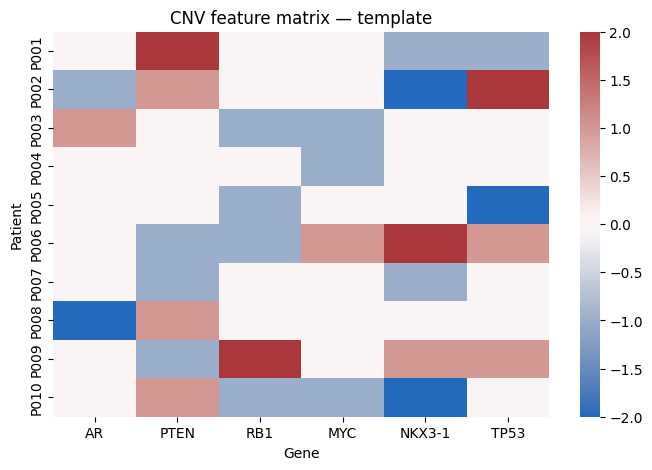

In [3]:
plt.figure(figsize=(8,5))
sns.heatmap(cnv, center=0, cmap="vlag")
plt.title("CNV feature matrix — template")
plt.xlabel("Gene"); plt.ylabel("Patient")
plt.show()


In [4]:
cnv_summary = pd.DataFrame({
    "amplification_rate":(cnv>0).mean(),
    "deletion_rate":(cnv<0).mean()
}).sort_values("amplification_rate", ascending=False)
display(cnv_summary)


,amplification_rate,deletion_rate
PTEN,0.4,0.3
TP53,0.3,0.2
NKX3-1,0.2,0.4
AR,0.1,0.2
MYC,0.1,0.3
RB1,0.1,0.4
